<a href="https://colab.research.google.com/github/masaki-kawa/uts-study-notes/blob/main/data/raw/colab/Deep_Learning_Lab4_Exercise1_Solutions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transfer Learning and Fine-Tuning

---

## Welcome to the fourth lab of Deep Learning!

This week, we will look at 2 very interesting topics before wrapping up our learning in Computer Vision: transfer learning and object detection.

By the end of this lab, you will be able to:
- import the relevant classes from PyTorch
- load existing CNN architecture and their pre-trained weights
- modify these existing architecture and fine-tune them
- setup and use the Pytorch Object Detection API

# Predicting cats versus dogs (binary classification)

## Dataset

The dataset we will be using is the Cats vs Dogs.

The data was originally shared by Microsoft in 2017.

Each observation is a color image representing either a dog or a cat..

The original dataset is avalaible here: [cats vs dogs](https://download.microsoft.com/download/3/e/1/3e1c3f21-ecdb-4869-8368-6deba77b919f/kagglecatsanddogs_5340.zip)

To make the model train faster we are going to sample the dataset.


## Objective

Our goal is to use a pre-trained Convolution Neural Network model and assess its performance then we will fine-tune it and see the impact.

## Instructions

This is a guided exercise where some of the code have already been pre-defined. Your task is to fill the remaining part of the code (it will be highlighted with placehoders) to train and evaluate your model.

This exercise is split in several parts:
1.   Loading and Exploration of the Dataset
2.   Preparing the Dataset
3.   Load a pre-trained VGG16 model
4.   Training and Evaluation of the VGG16 model

## Exercise 1 Solution

### 1. Loading and exploring the Dataset

**[1.1]** Let's start by importing the required libraries

In [ ]:
# Solution
# Import PyTorch and torchvision
import torch
import torchvision
import torchvision.transforms as transforms
import os

import random
import shutil
import zipfile
from pathlib import Path
from PIL import Image

**[1.2]**
First, we download the Cats and Dogs dataset locally from the alternative source. Then we save the path '/content/cats_and_dogs_filtered' in a variable called dataset_dir. We use Python's os.path.exists() method to check whether this directory exists. If it does not exist, we download the zip file, extract it, and organise the images into the expected train and validation folders.

In [ ]:
# Download and extract the dataset
random.seed(42)

file_url = "https://download.microsoft.com/download/3/e/1/3e1c3f21-ecdb-4869-8368-6deba77b919f/kagglecatsanddogs_5340.zip"

dataset_dir = Path("/content/cats_and_dogs_filtered")
zip_path = Path("/content/kagglecatsanddogs_5340.zip")
raw_dir = Path("/content/PetImages")

if not dataset_dir.exists():
    # Download
    if not zip_path.exists():
        !wget -O /content/kagglecatsanddogs_5340.zip "$file_url"

    # Extract
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall("/content")

    # Create the expected structure
    for split in ["train", "validation"]:
        for cls in ["cats", "dogs"]:
            (dataset_dir / split / cls).mkdir(parents=True, exist_ok=True)

    # Keep only valid JPGs
    def valid_images(folder):
        files = []
        for p in sorted(folder.glob("*.jpg")):
            try:
                with Image.open(p) as img:
                    img.verify()
                files.append(p)
            except Exception:
                pass
        return files

    cats = valid_images(raw_dir / "Cat")
    dogs = valid_images(raw_dir / "Dog")

    # Sample only 1000 train + 500 validation per class
    random.shuffle(cats)
    random.shuffle(dogs)
    cats = cats[:1500]
    dogs = dogs[:1500]

    def copy_split(files, cls_name):
        train_files = files[:1000]
        val_files = files[1000:1500]

        for src in train_files:
            shutil.copy2(src, dataset_dir / "train" / cls_name / src.name)

        for src in val_files:
            shutil.copy2(src, dataset_dir / "validation" / cls_name / src.name)

    copy_split(cats, "cats")
    copy_split(dogs, "dogs")

print("Dataset ready at:", dataset_dir)
print("Train cats:", len(list((dataset_dir / "train" / "cats").glob("*.jpg"))))
print("Train dogs:", len(list((dataset_dir / "train" / "dogs").glob("*.jpg"))))
print("Val cats:", len(list((dataset_dir / "validation" / "cats").glob("*.jpg"))))
print("Val dogs:", len(list((dataset_dir / "validation" / "dogs").glob("*.jpg"))))

--2026-03-15 01:10:20--  https://download.microsoft.com/download/3/e/1/3e1c3f21-ecdb-4869-8368-6deba77b919f/kagglecatsanddogs_5340.zip
Resolving download.microsoft.com (download.microsoft.com)... 23.14.134.46, 2600:1406:5400:2ac::317f, 2600:1406:5400:2ae::317f
Connecting to download.microsoft.com (download.microsoft.com)|23.14.134.46|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 824887076 (787M) [application/octet-stream]
Saving to: ‘/content/kagglecatsanddogs_5340.zip’

/content/kagglecats 100%[===================>] 786.67M   109MB/s    in 11s     

2026-03-15 01:10:31 (70.8 MB/s) - ‘/content/kagglecatsanddogs_5340.zip’ saved [824887076/824887076]



/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Dataset ready at: /content/cats_and_dogs_filtered
Train cats: 1000
Train dogs: 1000
Val cats: 500
Val dogs: 500


### 2.   Preparing the Dataset

**[2.1]** Apply transformation using compose class. This time we will not only normalize the images but we will also perform some data transformation such as RandomResizedCrop(100) [ https://pytorch.org/vision/main/generated/torchvision.transforms.RandomResizedCrop.html ] and RandomHorizontalFlip [ https://pytorch.org/vision/main/generated/torchvision.transforms.RandomHorizontalFlip.html ] for train data and Resize (100) and CenterCrop(100) for test data. Data augmentation is a good practice for the train set. Here, we randomly crop the image to 100x100 and randomly flip it horizontally. After then we will normalizes the tenosr images of train and test set using the normalize function of torchvision [ https://pytorch.org/vision/main/generated/torchvision.transforms.Normalize.html ].

In [ ]:
# Solution
# Define transformations
transform_train = transforms.Compose([
    transforms.RandomResizedCrop(100),                                            # Crop a random portion of image and resize it to a given size.
    transforms.RandomHorizontalFlip(),                                            # Horizontally flip the given image randomly
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # Normalize using ImageNet's mean and std values.
])

transform_test = transforms.Compose([
    transforms.Resize(100),                                                       # Resize the image to 100 pixels (keeping aspect ratio).
    transforms.CenterCrop(100),                                                   # Crop the center 100x100 region from the image.
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # Normalize using the same values as for training.
])

**[2.2]**
The images are already split into a 'train' and 'validation' folders under 'cats_and_dogs_filtered'

##### Task: Create 3 variables called train_dataset, test_dataset and full_dataset that will contain train, test data from the 'train' and 'validation' folders and combine the train and test data and save it into a variable called "full_dataset"

In [ ]:
# Solution
# Load training dataset
train_dataset = torchvision.datasets.ImageFolder(root=os.path.join(dataset_dir, 'train'), transform=transform_train)    # Apply training transformations

# Load test dataset
test_dataset = torchvision.datasets.ImageFolder(root=os.path.join(dataset_dir, 'validation'), transform=transform_test) # Apply test transformations

# Combine datasets
full_dataset = torch.utils.data.ConcatDataset([train_dataset, test_dataset])

**[2.3]**
Lets split the size of the full_dataset into train, test and validation data set according to following ratio 70%:15%:15% and save it into train_size, val_size and test_size.

In [ ]:
# Solution
# Calculate sizes for training, validation, and test sets
total_data = len(full_dataset)        # Total number of images in the full dataset
train_size = int(0.7 * total_data)    # 70% for training
val_size = int(0.15 * total_data)     # 15% for validation
test_size = int(0.15 * total_data)    # 15% for testing
print (total_data)
print (train_size)
print (val_size)
print (test_size)

3000
2100
450
450


**[2.4]**
According to the size of the dataset, now we will split a dataset into several subsets such as train_dataset,val_dataset, and test_dataset by using the random_split function (https://pytorch.org/docs/stable/data.html)

In [ ]:
# Solution
# Split the dataset
train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size, test_size])

**[2.5]**  Now we will call the DataLoader function that iteratively loads data based on batch size, shuffle and save it into three different variables called `train_loader`, `val_loader` and `test_loader`. Set the `BATCH_SIZE` to 20. The shuffle is a boolean variable. By default the shuffle value is false. If the shuffle is `True` means that the data is randomly shuffled before each epoch, so the order of the data is different in each epoch. (https://pytorch.org/tutorials/beginner/basics/data_tutorial.html)

In [ ]:
# Solution
# Define data loaders
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=20, shuffle=True)  # Shuffle training data
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=20, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=20, shuffle=False)

Note: Shuffling is crucial for training because it ensures that each mini-batch is a random sample of the entire dataset. This randomness prevents the model from learning spurious patterns from the order of the data and helps it generalize better. In contrast, the validation and test sets are kept in a fixed order to ensure that evaluation metrics remain consistent and reproducible. Since these sets are only used for assessing model performance (not for learning), shuffling them isn’t necessary.

**[2.6]**  Let's have a look at the length of `train_loader`, `val_loader`, and `test_loader`.

In [ ]:
# Solution
print(f"Size of train_loader: {len(train_loader)}")
print(f"Size of val_loader: {len(val_loader)}")
print(f"Size of test_loader: {len(test_loader)}")

Size of train_loader: 105
Size of val_loader: 23
Size of test_loader: 23


### 3.   Defining the Architecture of CNN

**[3.1]** Import `torch.nn` as `nn`, and to import VGG16 architecture we need to import `torchcision.models` as `models`

In [ ]:
# Solution
import torch.nn as nn
import torchvision.models as models

**[3.2]** No we will initialize the VGG16 model by specifying the parameter `pretrained = True`, (https://pytorch.org/vision/0.12/generated/torchvision.models.vgg16.html).

In [ ]:
# Solution
# Load pre-trained VGG16 model
vgg16 = models.vgg16(pretrained=True)   # Setting pretrained=True downloads the weights that have been trained on ImageNet.

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 184MB/s]


**[3.3]** Let's freeze all layers of the model by setting the value of `requires_grad` as `false`, i.e. no changes happen to its parameters. (https://pytorch.org/docs/stable/generated/torch.Tensor.requires_grad.html#torch.Tensor.requires_grad)

In [ ]:
# Solution
# Freeze all layers for param in model.parameters()
for param in vgg16.parameters():
    param.requires_grad = False

**[3.4]** Let's have a look at the VGG16 architecture

##### Task: Print the summary of the VGG16 model

In [ ]:
# Solution
print(vgg16)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

**[3.5]** As you can see, we have now a VGG16 model with no parameters update and top layers used for making the predictions. We will add 2 fully connected layers to the VGG16.

##### Task: Create a new model by replacing the final fully-connected layer of the VGG16 model with 2 new fully connnected layers (respectively with 500 and 1 units and Relu and Sigmoid activation functions)

In [ ]:
# Solution
# Modify last layer for binary classification
# Replace the last layer with a new Sequential module that includes:

vgg16.classifier[6] = nn.Sequential(
    nn.Linear(4096, 500),             # - A Linear layer reducing from 4096 features to 500
    nn.ReLU(),                        # - A ReLU activation function
    nn.Linear(500, 1),                # - A final Linear layer reducing from 500 to 1 (for binary classification)
    nn.Sigmoid()                      # - A Sigmoid activation to output a probability between 0 and 1.
)

**[3.6]** After modifying the last layer of VGG16, let's have a look at the modified VGG16 architecture

##### Task: Print the summary of newly modified VGG16 model

In [ ]:
# Solution
# Print summary
print(vgg16)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

### 4. Training and Evaluation of the Model

**[4.1]** Let's create a variable called `device` that will automatically select a GPU if available. Otherwise it will default to CPU.

In [ ]:
# Solution
# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

**[4.2]**  Instantiate a `nn.BCELoss()` and save it into a variable called `criterion`. After then Instantiate a `torch.optim.Adam()` optimizer with the model's parameters and 0.0001 as learning rate and save it into a variable called `optimizer`

In [ ]:
# Solution
# Define loss function and optimizer
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(vgg16.parameters(), lr=0.0001)

**[4.3]**  Let's move model to `device`

In [ ]:
# Solution
# Move model to device
vgg16.to(device)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

**[4.4]** **Training:** Now it is time to train our model. Set the `EPOCHS` to 5 and create a for loop that will iterate based on the EPOCHS value. A nested loop is initiated that extracts images and labels from `train_loader` and introduce the following logics:
- reset the gradients (https://pytorch.org/docs/stable/generated/torch.optim.Optimizer.zero_grad.html)
- perform the forward propagation and get the model predictions
- calculate the loss between the predictions and the actuals
- perform back propagation
- update the weights
- Count the total loss

To validate the model a nested loop is initiated that extracts images and labels from `val_loader` and introduce the following logics:
- disable computing gradients (https://pytorch.org/docs/stable/generated/torch.no_grad.html)
- perform the forward propagation and get the model predictions
- calculate the loss between the predictions and the actuals
- Count the total loss
- Count the correct outcome

In [ ]:
# Solution
import numpy as np
import matplotlib.pyplot as plt

# Lists to store training and validation losses and accuracies for plotting later.
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

# Train the model
num_epochs = 5                    # Number of epochs for training

for epoch in range(num_epochs):
    vgg16.train()                 # Set the model to training mode
    running_loss = 0.0            # Accumulate training loss for the current epoch
    correct_train = 0             # Count correct predictions for training
    total_train = 0               # Total training samples processed

    # Iterate over batches from the training loader.
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)   # Move data to the device
        optimizer.zero_grad()                                   # Reset the gradients
        outputs = vgg16(images)                                 # Forward Propagation to get predicted outcome
        loss = criterion(outputs.squeeze(), labels.float())     # Compute the loss, Note: squeeze is used to remove extra dimensions.
        loss.backward()                                         # Back propagation
        optimizer.step()                                        # Update the weights
        running_loss += loss.item()                             # Count the total loss

        # Calculate training accuracy
        predicted = torch.round(outputs).squeeze()              # Round the predictions to 0 or 1 and compare to actual labels.
        correct_train += (predicted == labels).sum().item()
        total_train += labels.size(0)

    # Calculate training loss and accuracy
    epoch_loss_train = running_loss / len(train_loader)
    train_losses.append(epoch_loss_train)
    train_accuracy = correct_train / total_train
    train_accuracies.append(train_accuracy)

    # Calculate validation loss and accuracy
    vgg16.eval()            # Set model to evaluation mode
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():                                               # Disable gradient calculation to speed up inference and reduce memory usage.
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = vgg16(images)                                     # Forward Propagation to get predicted outcome
            val_loss = criterion(outputs.squeeze(), labels.float())     # Compute the validation loss
            running_val_loss += val_loss.item()                         # Count the total loss
            predicted = torch.round(outputs).squeeze()
            correct_val += (predicted == labels).sum().item()           # Compare between the predicted and actual
            total_val += labels.size(0)

    # Calculate validation loss and accuracy.
    epoch_loss_val = running_val_loss / len(val_loader)
    val_losses.append(running_val_loss / len(val_loader))
    val_accuracy = correct_val / total_val
    val_accuracies.append(val_accuracy)

   # Print epoch results  #Training Loss: {epoch_loss:.4f}, \ Validation Loss: {val_losses[-1]:.4f}, \
    print(f"Epoch [{epoch + 1}/{num_epochs}], \
          Training Loss: {epoch_loss_train:.4f}, \
          Training Accuracy: {train_accuracy:.2%}, \
          Validation Loss: {epoch_loss_val:.4f}, \
          Validation Accuracy: {val_accuracy:.2%}")

Epoch [1/5],           Training Loss: 0.2002,           Training Accuracy: 91.10%,           Validation Loss: 0.1172,           Validation Accuracy: 95.33%
Epoch [2/5],           Training Loss: 0.1349,           Training Accuracy: 94.19%,           Validation Loss: 0.1031,           Validation Accuracy: 95.78%
Epoch [3/5],           Training Loss: 0.1273,           Training Accuracy: 94.48%,           Validation Loss: 0.1128,           Validation Accuracy: 94.89%
Epoch [4/5],           Training Loss: 0.1142,           Training Accuracy: 95.48%,           Validation Loss: 0.1121,           Validation Accuracy: 95.11%
Epoch [5/5],           Training Loss: 0.1167,           Training Accuracy: 95.05%,           Validation Loss: 0.1361,           Validation Accuracy: 94.00%


**[4.7]** **Testing:** Now it is time to test our model. Initiate the `model.eval()` along with `torch.no_grad()` to turn off the gradients. Finally calculate the total and correct value.

In [ ]:
# Solution
# Evaluate the model on test set
correct = 0
total = 0

# Switch to evaluation mode and disable gradient calculation.
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = vgg16(images)
        predicted = torch.round(outputs).squeeze()
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = correct / total
print(f'Accuracy on test set: {test_accuracy:.2%}')

Accuracy on test set: 94.44%


### 5. Analysing the Results

**[5.1]** Let's plot the training and validation losses

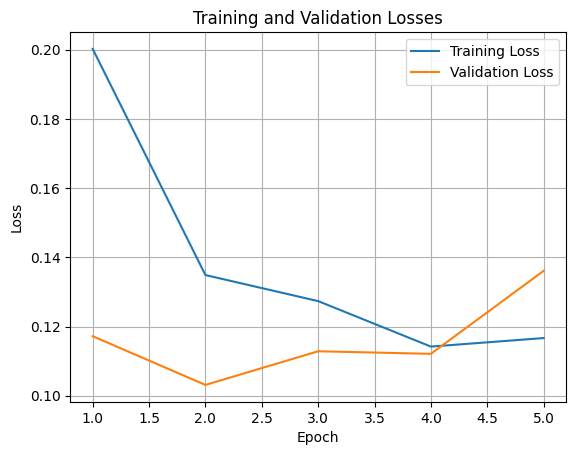

In [ ]:
# Solution
# Plot training and validation losses starting from index 1
epochs = range(1, len(train_losses) + 1)  # Generate the range of epochs starting from 1

# Plot training and validation losses
plt.plot(epochs, train_losses, label='Training Loss')   # Plot training losses over epochs
plt.plot(epochs, val_losses, label='Validation Loss')   # Plot validation losses over epochs
plt.xlabel('Epoch')                                     # Set label for the x-axis
plt.ylabel('Loss')                                      # Set label for the y-axis
plt.title('Training and Validation Losses')             # Set title for the plot
plt.legend()                                            # Display legend
plt.grid(True)                                          # Display grid
plt.show()                                              # Show the plot

**[5.2]** Let's plot the training and validation accuracy

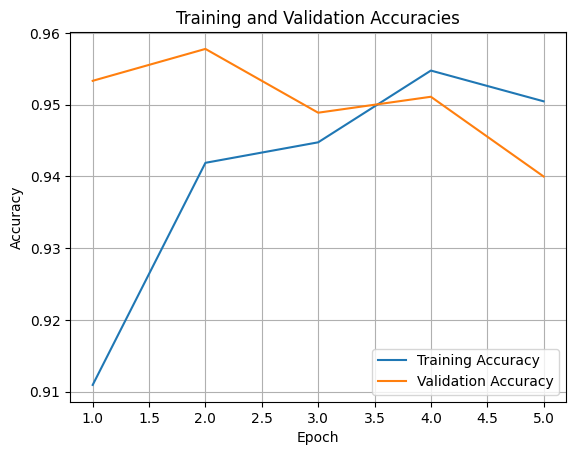

In [ ]:
# Solution
# Plot training and validation accuracies starting from index 1
epochs = range(1, len(train_accuracies) + 1)  # Generate the range of epochs starting from 1

# Plot training and validation accuracies
plt.plot(epochs, train_accuracies, label='Training Accuracy')   # Plot training accuracies over epochs
plt.plot(epochs, val_accuracies, label='Validation Accuracy')   # Plot validation accuracies over epochs
plt.xlabel('Epoch')                                             # Set label for the x-axis
plt.ylabel('Accuracy')                                          # Set label for the y-axis
plt.title('Training and Validation Accuracies')                 # Set title for the plot
plt.legend()                                                    # Display legend
plt.grid(True)                                                  # Display grid
plt.show()                                                      # Show the plot


Last week we trained a VGG16 model from scratch for 5 epochs and it achieved an accuracy around 50%. Here we used a pre-trained model and only updated the weights of the final layers and achieved an accuracy more than 93% just after 5 epochs. We can achieve better results if we train for longer. Amazing, right? This is the benfits of using transfer learning.